In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset("penguins")

In [2]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
# Eliminar filas con valores nulos
penguins = penguins.dropna().reset_index(drop=True)

In [4]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## 🧩 Ejercicio 1 – Cálculos con NumPy (25%)

1. A partir de la columna `body_mass_g`, crea un arreglo de NumPy llamado `mass_array`.
2. Calcula e imprime:
   - La **media** del peso corporal (`body_mass_g`).
   - La **mediana** del peso corporal.
   - El **mínimo** y **máximo** del peso corporal.



In [ ]:
mass_array = np.array(penguins['body_mass_g'])

In [8]:
media = np.mean(mass_array)
print(f'La media es : {media:.2f} g')

La media es : 4207.06 g



## 📊 Ejercicio 2 – Agrupaciones y sumatorias con Pandas (25%)

Usando **pandas**, realiza lo siguiente:

1. Agrupa el DataFrame `penguins` por la columna `species`.
2. Calcula para cada especie:
   - La **suma total** del peso corporal (`body_mass_g`).
   - El **número de individuos** (conteo de filas).
3. Guarda el resultado en un DataFrame llamado `resumen_species` con las columnas:
   - `total_mass`
   - `count_penguins`
4. Ordena `resumen_species` de mayor a menor según `total_mass` y muéstralo.

---


In [15]:
resumen_species = (
  penguins.groupby('species')
  .agg(mean_mass=('body_mass_g', 'mean'))
  .sort_values('mean_mass',ascending=False)
  .reset_index()
)
resumen_species

,species,mean_mass
0,Gentoo,5092.436975
1,Chinstrap,3733.088235
2,Adelie,3706.164384



## 📈 Ejercicio 3 – Visualización con Matplotlib (25%)

Usando el DataFrame `resumen_species` del ejercicio anterior:

1. Crea un **gráfico de barras** con **Matplotlib** donde:
   - El eje X sea la **especie**.
   - El eje Y sea la **suma total de masa corporal (`total_mass`)**.
2. Agrega:
   - Un **título** descriptivo.
   - Nombres a los ejes: `"Especie"` (X) y `"Suma total de masa corporal (g)"` (Y).
---


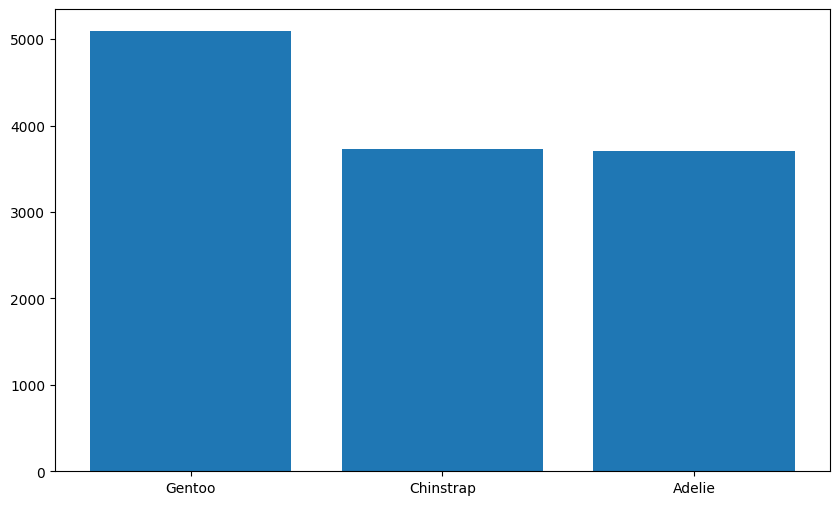

In [16]:
plt.figure(figsize=(10, 6))
x = resumen_species['species']
y = resumen_species['mean_mass']
plt.bar(x,y)
plt.show()


## 🌈 Ejercicio 4 – Scatterplot con Seaborn (25%)

Usando **seaborn** y el DataFrame `penguins`:

1. Crea un **diagrama de dispersión (scatterplot)** donde:
   - Eje X → `bill_length_mm`
   - Eje Y → `bill_depth_mm`
2. El color (`hue`) debe representar la **especie (`species`)**.
3. El estilo o forma de los puntos (`style`) debe representar el **sexo (`sex`)

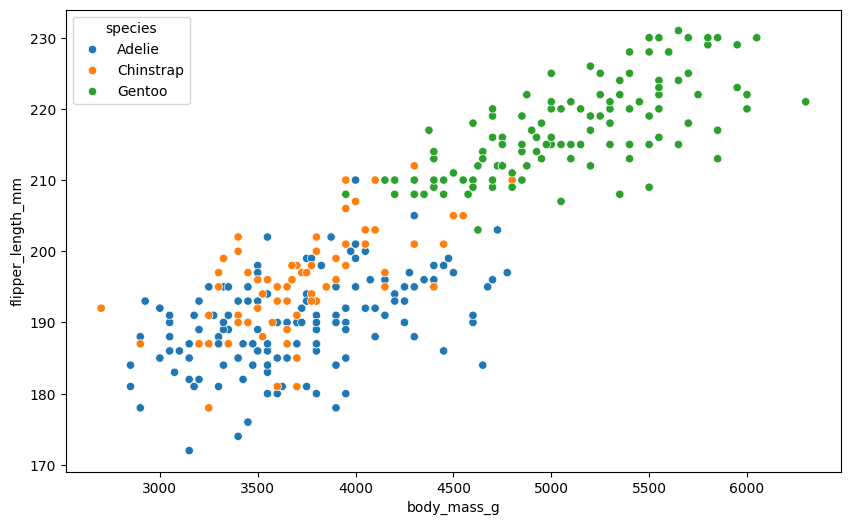

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=penguins,
    x='body_mass_g',
    y='flipper_length_mm',
    hue='species'
)
plt.show()